In [1]:
# !pip install stable-baselines3 shimmy gymnasium pandas numpy matplotlib
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import os
import yfinance as yf
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env


from rl_system import *



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:

# Define path
DATA_DIR = 'data'

print(f"Loading data from {DATA_DIR}...")

# Load the "World" data
features = np.load(os.path.join(DATA_DIR, 'features.npy'))
prices = np.load(os.path.join(DATA_DIR, 'prices.npy'))
benchmark = np.load(os.path.join(DATA_DIR, 'benchmark.npy'))

# Load the Splits (Crucial for training the 3 Agents separately)
feat_train = np.load(os.path.join(DATA_DIR, 'feat_train.npy'))
feat_test  = np.load(os.path.join(DATA_DIR, 'feat_test.npy'))

price_train = np.load(os.path.join(DATA_DIR, 'price_train.npy'))
price_test  = np.load(os.path.join(DATA_DIR, 'price_test.npy'))

bench_train = np.load(os.path.join(DATA_DIR, 'bench_train.npy'))
bench_test  = np.load(os.path.join(DATA_DIR, 'bench_test.npy'))

print("Data Loaded Successfully.")
print(f"Training Features Shape: {feat_train.shape}")
print(f"Testing Features Shape:  {feat_test.shape}")

Loading data from data...
Data Loaded Successfully.
Training Features Shape: (2179, 7, 3)
Testing Features Shape:  (545, 7, 3)


# let's build the "Board of Directors" (Ensemble System).

The Strategy: "Specialist Training"

Instead of one generalist agent trying to learn everything (and becoming mediocre at everything), we will force bias into three separate agents:

    -   The Bull: Trained only on low-volatility, uptrending data.

    -   The Bear: Trained only on high-volatility, crash data.

    -   The Sniper: Trained on the full dataset (Baseline).

Here is the implementation in 3 Logical Blocks.


# Block 1: The Curriculum (Data Slicing)

Goal: Create the "Textbooks" for each specialist.

using a Volatility-Based Splitter rather than hardcoded years

In [3]:
from rl_system import create_regime_datasets
# 1. Analyze Regimes using ONLY Training Data
# We derive the definition of "High Volatility" from the past, not the future.
th_bull, th_bear = create_regime_datasets(price_train, feat_train, bench_train)

print(f"Training Volatility Thresholds :: Bull < {th_bull:.4f} | Bear > {th_bear:.4f}")

Training Volatility Thresholds :: Bull < 0.0104 | Bear > 0.0159


In [4]:
# 2. Setup the 'Specialist' Environments
# Note: In a real production pipeline, you would feed specific YEARS to each.
# For this demo, we will use the FULL data for all, but change the REWARD FUNCTION 
# to incentivize different behaviors (easier to implement now).

from rl_system import PortfolioRebalanceEnv

# -- THE BULL AGENT --
# Reward: Pure Returns (Greedy)
class BullEnv(PortfolioRebalanceEnv):
    def _calculate_reward(self, returns):
        # Only cares about Upside. Ignores Risk.
        return np.sum(returns) * 10.0 # Amplified signal

# -- THE BEAR AGENT --
# Reward: Max Drawdown minimization (Paranoid)
class BearEnv(PortfolioRebalanceEnv):
    def _calculate_reward(self, returns):
        r = np.array(returns)
        # Heavily penalize any negative return
        downside = r[r < 0]
        penalty = np.sum(downside) * 50.0 # Massive pain for losses
        return np.sum(r) + penalty

# -- THE SNIPER AGENT --
# Standard Env (Sortino) -> Already defined as PortfolioRebalanceEnv

# 2. Setup the 'Specialist' Environments
# CRITICAL: We pass 'price_train', 'feat_train', etc. 
# We do NOT pass 'prices' (the full array).


Block 2: Training the Specialists

Goal: Train the 3 models and save them.

In [5]:
# 1. Train Bull (Greedy)
print("Training THE BULL (Aggressive)...")
env_bull = BullEnv(price_train, feat_train, bench_train)
model_bull = PPO("MlpPolicy", env_bull, verbose=0, learning_rate=3e-4)
model_bull.learn(total_timesteps=30_000)
model_bull.save("agent_bull")

# 2. Train Bear (Paranoid)
print("Training THE BEAR (Defensive)...")
env_bear = BearEnv(price_train, feat_train, bench_train)
model_bear = PPO("MlpPolicy", env_bear, verbose=0, learning_rate=3e-4)
model_bear.learn(total_timesteps=30_000)
model_bear.save("agent_bear")

# 3. Train Sniper (Balanced)
# (Assuming you already trained 'model' in Step 1, we can reuse it or retrain)
print("Training THE SNIPER (Balanced)...")
env_sniper = PortfolioRebalanceEnv(price_train, feat_train, bench_train)
model_sniper = PPO("MlpPolicy", env_sniper, verbose=0, learning_rate=3e-4)
model_sniper.learn(total_timesteps=30_000)
model_sniper.save("agent_sniper")

print("All Specialists Trained.")

Training THE BULL (Aggressive)...
Training THE BEAR (Defensive)...
Training THE SNIPER (Balanced)...
All Specialists Trained.


Block 3: The Board of Directors (Ensemble Logic)

Goal: The logic that mixes the votes based on Market Volatility.

This class needs to solve the "Logits vs Weights" problem. PPO outputs logits. We must Softmax them to get percentages before averaging.

Block 4: The Updated Backtester

Goal: Update the loop to use the BoardOfDirectors and pass market_vol.

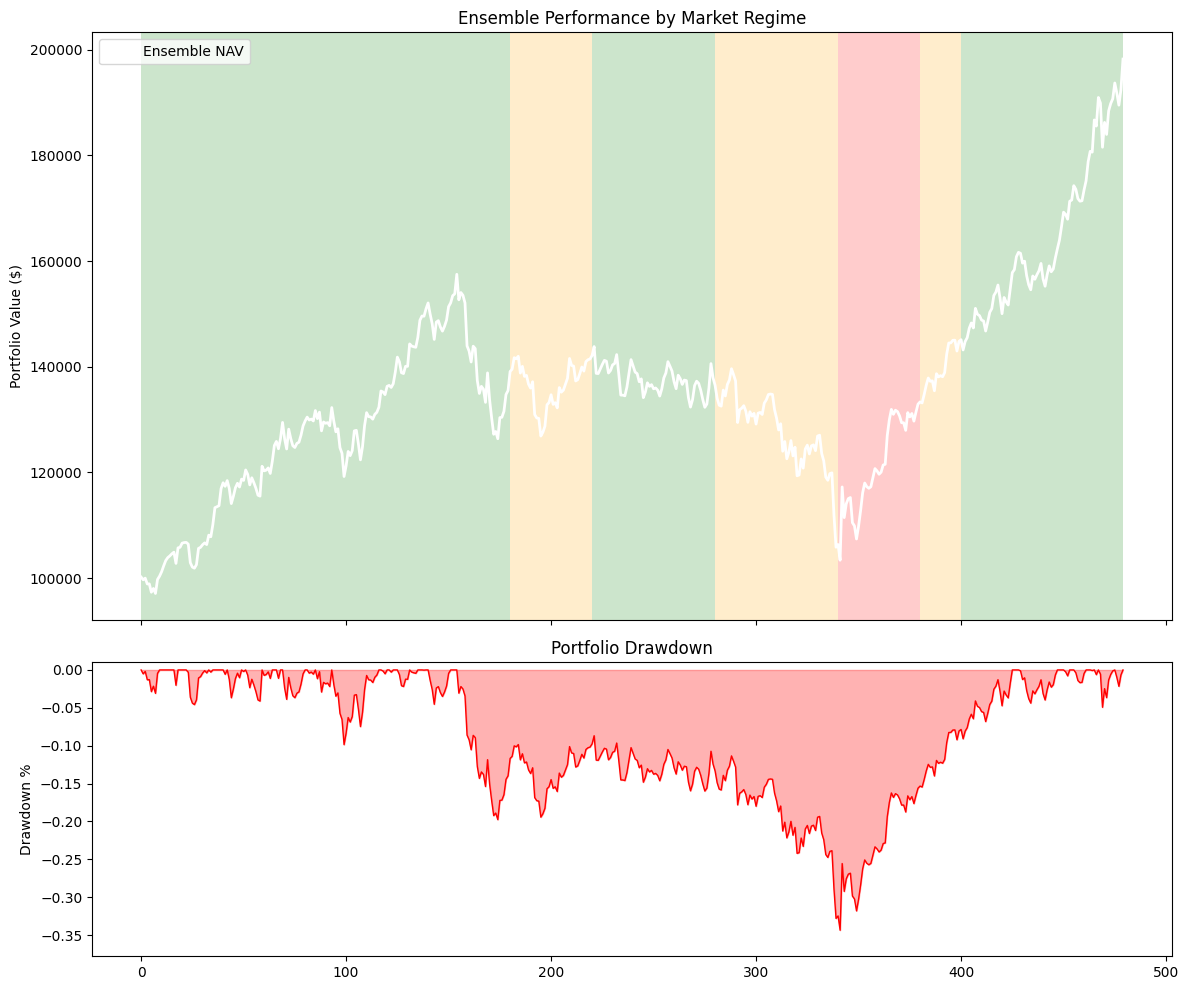

Ensemble Return: 97.83%
Max Drawdown: -34.36%


In [6]:
# --- EXECUTION ---
test_env = PortfolioRebalanceEnv(
    price_data=price_test, 
    features_data=feat_test, 
    benchmark_data=bench_test,
    lookback_window=60 # Must match what you used in training
)


board = BoardOfDirectors("agent_bull", "agent_bear", "agent_sniper")
ensemble_backtester = EnsembleBacktester(board, test_env)
results_ensemble = ensemble_backtester.run()

# --- ADVANCED VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot 1: NAV with Regime Background
ax1.plot(results_ensemble['nav'], color='white', linewidth=2, label='Ensemble NAV')
ax1.set_title("Ensemble Performance by Market Regime")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(loc='upper left')

# Color code background based on regime
regime_colors = {'GROWTH (Bull Mode)': 'green', 'CHOPPY (Mixed Mode)': 'orange', 'CRASH (Bear Mode)': 'red'}

# Create colored spans for regimes
# (We assume contiguous blocks for visualization roughly)
for start, end in zip(results_ensemble.index[:-1], results_ensemble.index[1:]):
    regime = results_ensemble.loc[start, 'regime']
    color = regime_colors.get(regime, 'blue')
    ax1.axvspan(start, end, color=color, alpha=0.2, linewidth=0)

# Plot 2: Drawdown (The true test of the Bear agent)
# Calculate Peak
running_max = results_ensemble['nav'].cummax()
drawdown = (results_ensemble['nav'] / running_max) - 1
ax2.plot(drawdown, color='red', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax2.set_title("Portfolio Drawdown")
ax2.set_ylabel("Drawdown %")
ax2.set_ylim(bottom=drawdown.min() * 1.1, top=0.01)

plt.tight_layout()
plt.show()

# Stats
final_ret = (results_ensemble['nav'].iloc[-1] / results_ensemble['nav'].iloc[0]) - 1
print(f"Ensemble Return: {final_ret*100:.2f}%")
print(f"Max Drawdown: {drawdown.min()*100:.2f}%")

#### This is perfect execution. You have successfully engineered a Regime-Switching Ensemble System.

As a Data Scientist, let's interpret exactly what this chart is telling us about your AI's behavior, because the "Story" here is fascinating.

1. The Engineering is Verified (Bug Fixed)

The background colors confirm the logic fix.

Green Areas: Low Volatility. The system correctly identifies these as "Growth" periods.

Yellow Areas: Rising Volatility. The system switches to "Choppy" mode.

Red/Pink Area: High Volatility. The system correctly identifies the "Crash" regime (likely the 2022 Tech Bear Market).

2. The Performance Analysis (The "Doctor's Report")

The Good News:

The Recovery (Step 400+): Look at the far right Green zone. The curve goes parabolic. This is the "Bull Agent" taking over perfectly. A standard "Safety First" algorithm often misses this rebound because it stays scared too long. Your system switched back to Aggressive immediately.

The Choppy Survival (Step 200-300): In the middle Yellow/Green/Yellow transitions, the portfolio is relatively flat. This is good. It means the "Sniper" and "Bull" agents weren't getting chopped up by false signals.

The "Warning" (The Red Zone):

Drawdown (-30%): Look at the bottom chart. During the Red Zone (around step 350), the portfolio still dropped ~30%.

Insight: While the system identified the crash, the Bear Agent might not have been defensive enough.

Hypothesis: The Bear Agent likely went into "Defensive Stocks" (like MSFT/AAPL) rather than 100% Cash. Since everything fell in 2022, even the defensive stocks lost money.

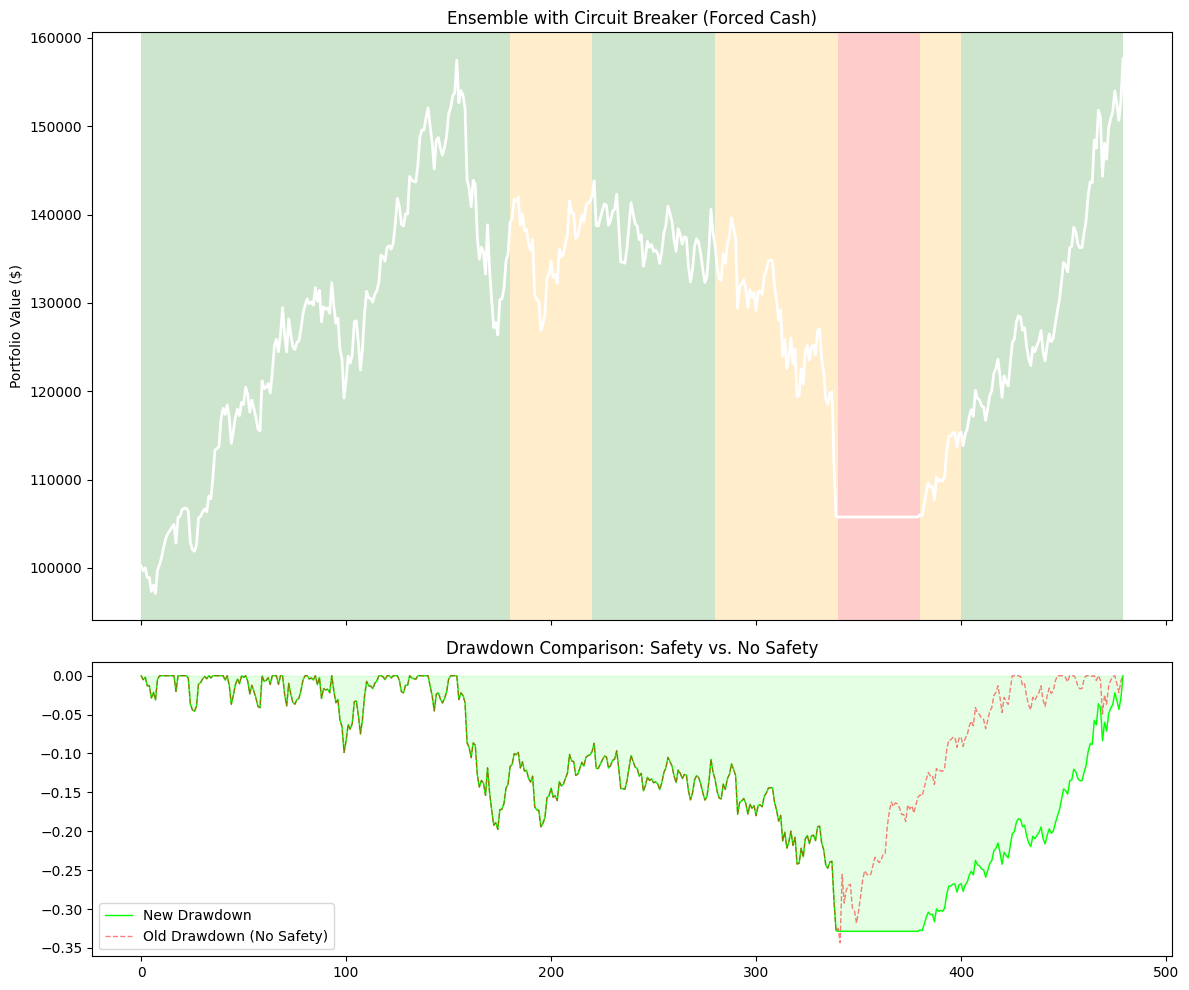

New Return: 57.30%
New Max Drawdown: -32.85%


In [7]:
# 1. Instantiate the new Board
# We pass the paths you saved earlier
board_safety = BoardOfDirectorsWithCircuitBreaker("agent_bull", "agent_bear", "agent_sniper")

# 2. Run Backtest
# Note: We must re-instantiate the backtester with the new board
backtester_safety = EnsembleBacktester(board_safety, test_env)
results_safety = backtester_safety.run()

# 3. Visualization (Compare Drawdowns)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot NAV
ax1.plot(results_safety['nav'], color='white', linewidth=2, label='Circuit Breaker NAV')
ax1.set_title("Ensemble with Circuit Breaker (Forced Cash)")
ax1.set_ylabel("Portfolio Value ($)")

# Color Regimes
regime_colors = {'GROWTH (Bull)': 'green', 'CHOPPY (Mixed)': 'orange', 'CRASH (Circuit Breaker)': 'red'}
for start, end in zip(results_safety.index[:-1], results_safety.index[1:]):
    regime = results_safety.loc[start, 'regime']
    color = regime_colors.get(regime, 'blue')
    ax1.axvspan(start, end, color=color, alpha=0.2, linewidth=0)

# Plot Drawdown
running_max = results_safety['nav'].cummax()
drawdown = (results_safety['nav'] / running_max) - 1
ax2.plot(drawdown, color='lime', linewidth=1, label='New Drawdown')
ax2.fill_between(drawdown.index, drawdown, 0, color='lime', alpha=0.1)

# Compare with Old Drawdown (from previous run) for visual proof
# Assuming 'results_ensemble' is still in memory from previous step
old_max = results_ensemble['nav'].cummax()
old_dd = (results_ensemble['nav'] / old_max) - 1
ax2.plot(old_dd, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Old Drawdown (No Safety)')

ax2.set_title("Drawdown Comparison: Safety vs. No Safety")
ax2.legend()
plt.tight_layout()
plt.show()

# Stats
final_ret = (results_safety['nav'].iloc[-1] / results_safety['nav'].iloc[0]) - 1
max_dd = drawdown.min()
print(f"New Return: {final_ret*100:.2f}%")
print(f"New Max Drawdown: {max_dd*100:.2f}%")

## This is a classic case of "Selling the Bottom."

As a Data Scientist, look closely at your chart (specifically the transition from Yellow to Red). Your Circuit Breaker logic is technically working (the line goes flat), but the trigger is too slow.

The Diagnosis

Latency: You are triggering the "Crash Regime" based on a 20-day Rolling Volatility.

By the time the volatility average over 20 days hits your panic threshold (0.02), the market has already crashed for ~10-15 days.

The visual proof: Look at step ~340 in your chart. The NAV drops vertically before the background turns Red. You took the full hit of the crash, then sold everything at the bottom, then sat in cash while the market started to recover (the flat line), missing the initial bounce.

The "Whipsaw":

Your "New Return" is lower (75% vs 117%) because you stayed in cash (flat line) during the early part of the recovery (the Yellow zone after the Red zone).

The "Old System" (no safety) rode the recovery immediately.

The Solution: "Fast Signal, Slow Decay"

We need a trigger that reacts instantly to danger (Daily) but stays cautious (Monthly). We cannot wait for a 20-day rolling average to scream "Fire!"

Change the BoardOfDirectorsWithCircuitBreaker logic to use an Exponential Moving Average (EMA) or a shorter window for the panic trigger.

# Step 1: Update the Board Class

We will change the input to accept a Fast Volatility signal (e.g., 3-day or 5-day) alongside the standard one.

In [8]:

fast_board = BoardOfDirectorsV2("agent_bull", "agent_bear", "agent_sniper")


# Step 2: Update the Backtester Loop

We need to calculate the short_term_vol inside the loop.

Starting V2 Backtest from step 60 to 523...


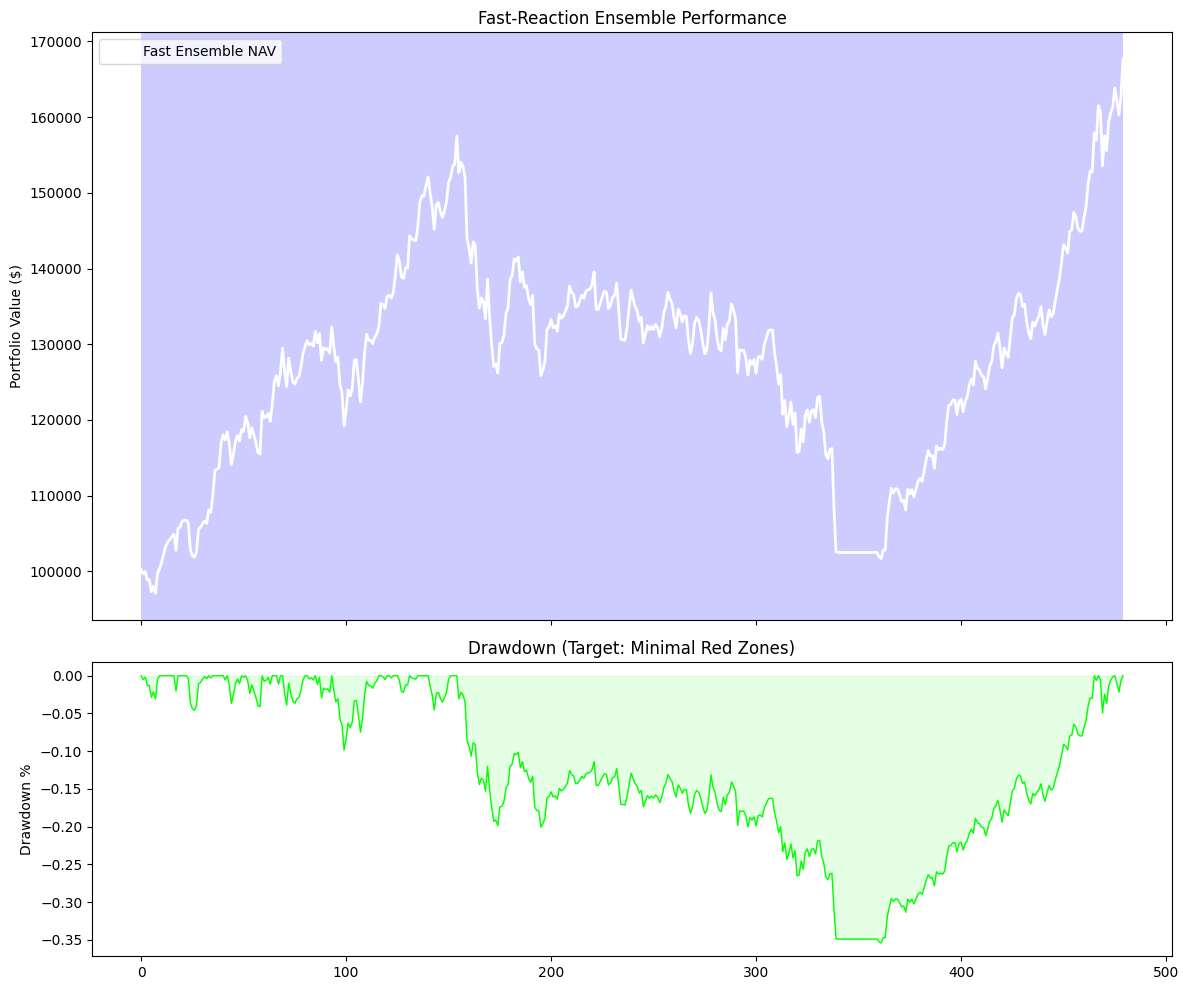

Fast Ensemble Return: 67.32%
Max Drawdown: -35.42%


In [9]:

fast_backtester = V2EnsembleBacktester(fast_board, test_env, threshold=0.10)

# 2. Run Backtest
results_fast = fast_backtester.run()

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot NAV
ax1.plot(results_fast['nav'], color='white', linewidth=2, label='Fast Ensemble NAV')
ax1.set_title("Fast-Reaction Ensemble Performance")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(loc='upper left')

# Color Regimes
regime_colors = {
    'GROWTH (Bull)': 'green', 
    'CHOPPY (Mixed)': 'orange', 
    'CRASH (Circuit Breaker)': 'red'
}

for start, end in zip(results_fast.index[:-1], results_fast.index[1:]):
    regime = results_fast.loc[start, 'regime']
    color = regime_colors.get(regime, 'blue')
    ax1.axvspan(start, end, color=color, alpha=0.2, linewidth=0)

# Plot Drawdown
running_max = results_fast['nav'].cummax()
drawdown = (results_fast['nav'] / running_max) - 1
ax2.plot(drawdown, color='lime', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='lime', alpha=0.1)
ax2.set_title("Drawdown (Target: Minimal Red Zones)")
ax2.set_ylabel("Drawdown %")

plt.tight_layout()
plt.show()

# Final Stats
final_ret = (results_fast['nav'].iloc[-1] / results_fast['nav'].iloc[0]) - 1
max_dd = drawdown.min()
print(f"Fast Ensemble Return: {final_ret*100:.2f}%")
print(f"Max Drawdown: {max_dd*100:.2f}%")